f_b = Omega_b / Omega_m = 0.1565
eta_star = 281.21 Mpc
eta_d    = 287.10 Mpc
r_s(eta_d) = 147.51 Mpc  (integral com R(eta) variavel)
Planck 2018: r_s = 147.05 Mpc -> erro = 0.3%

Defasagem entre os sinais: Delta_phi = pi/2 = 1.5708 rad

Grafico 4 salvo com sucesso.


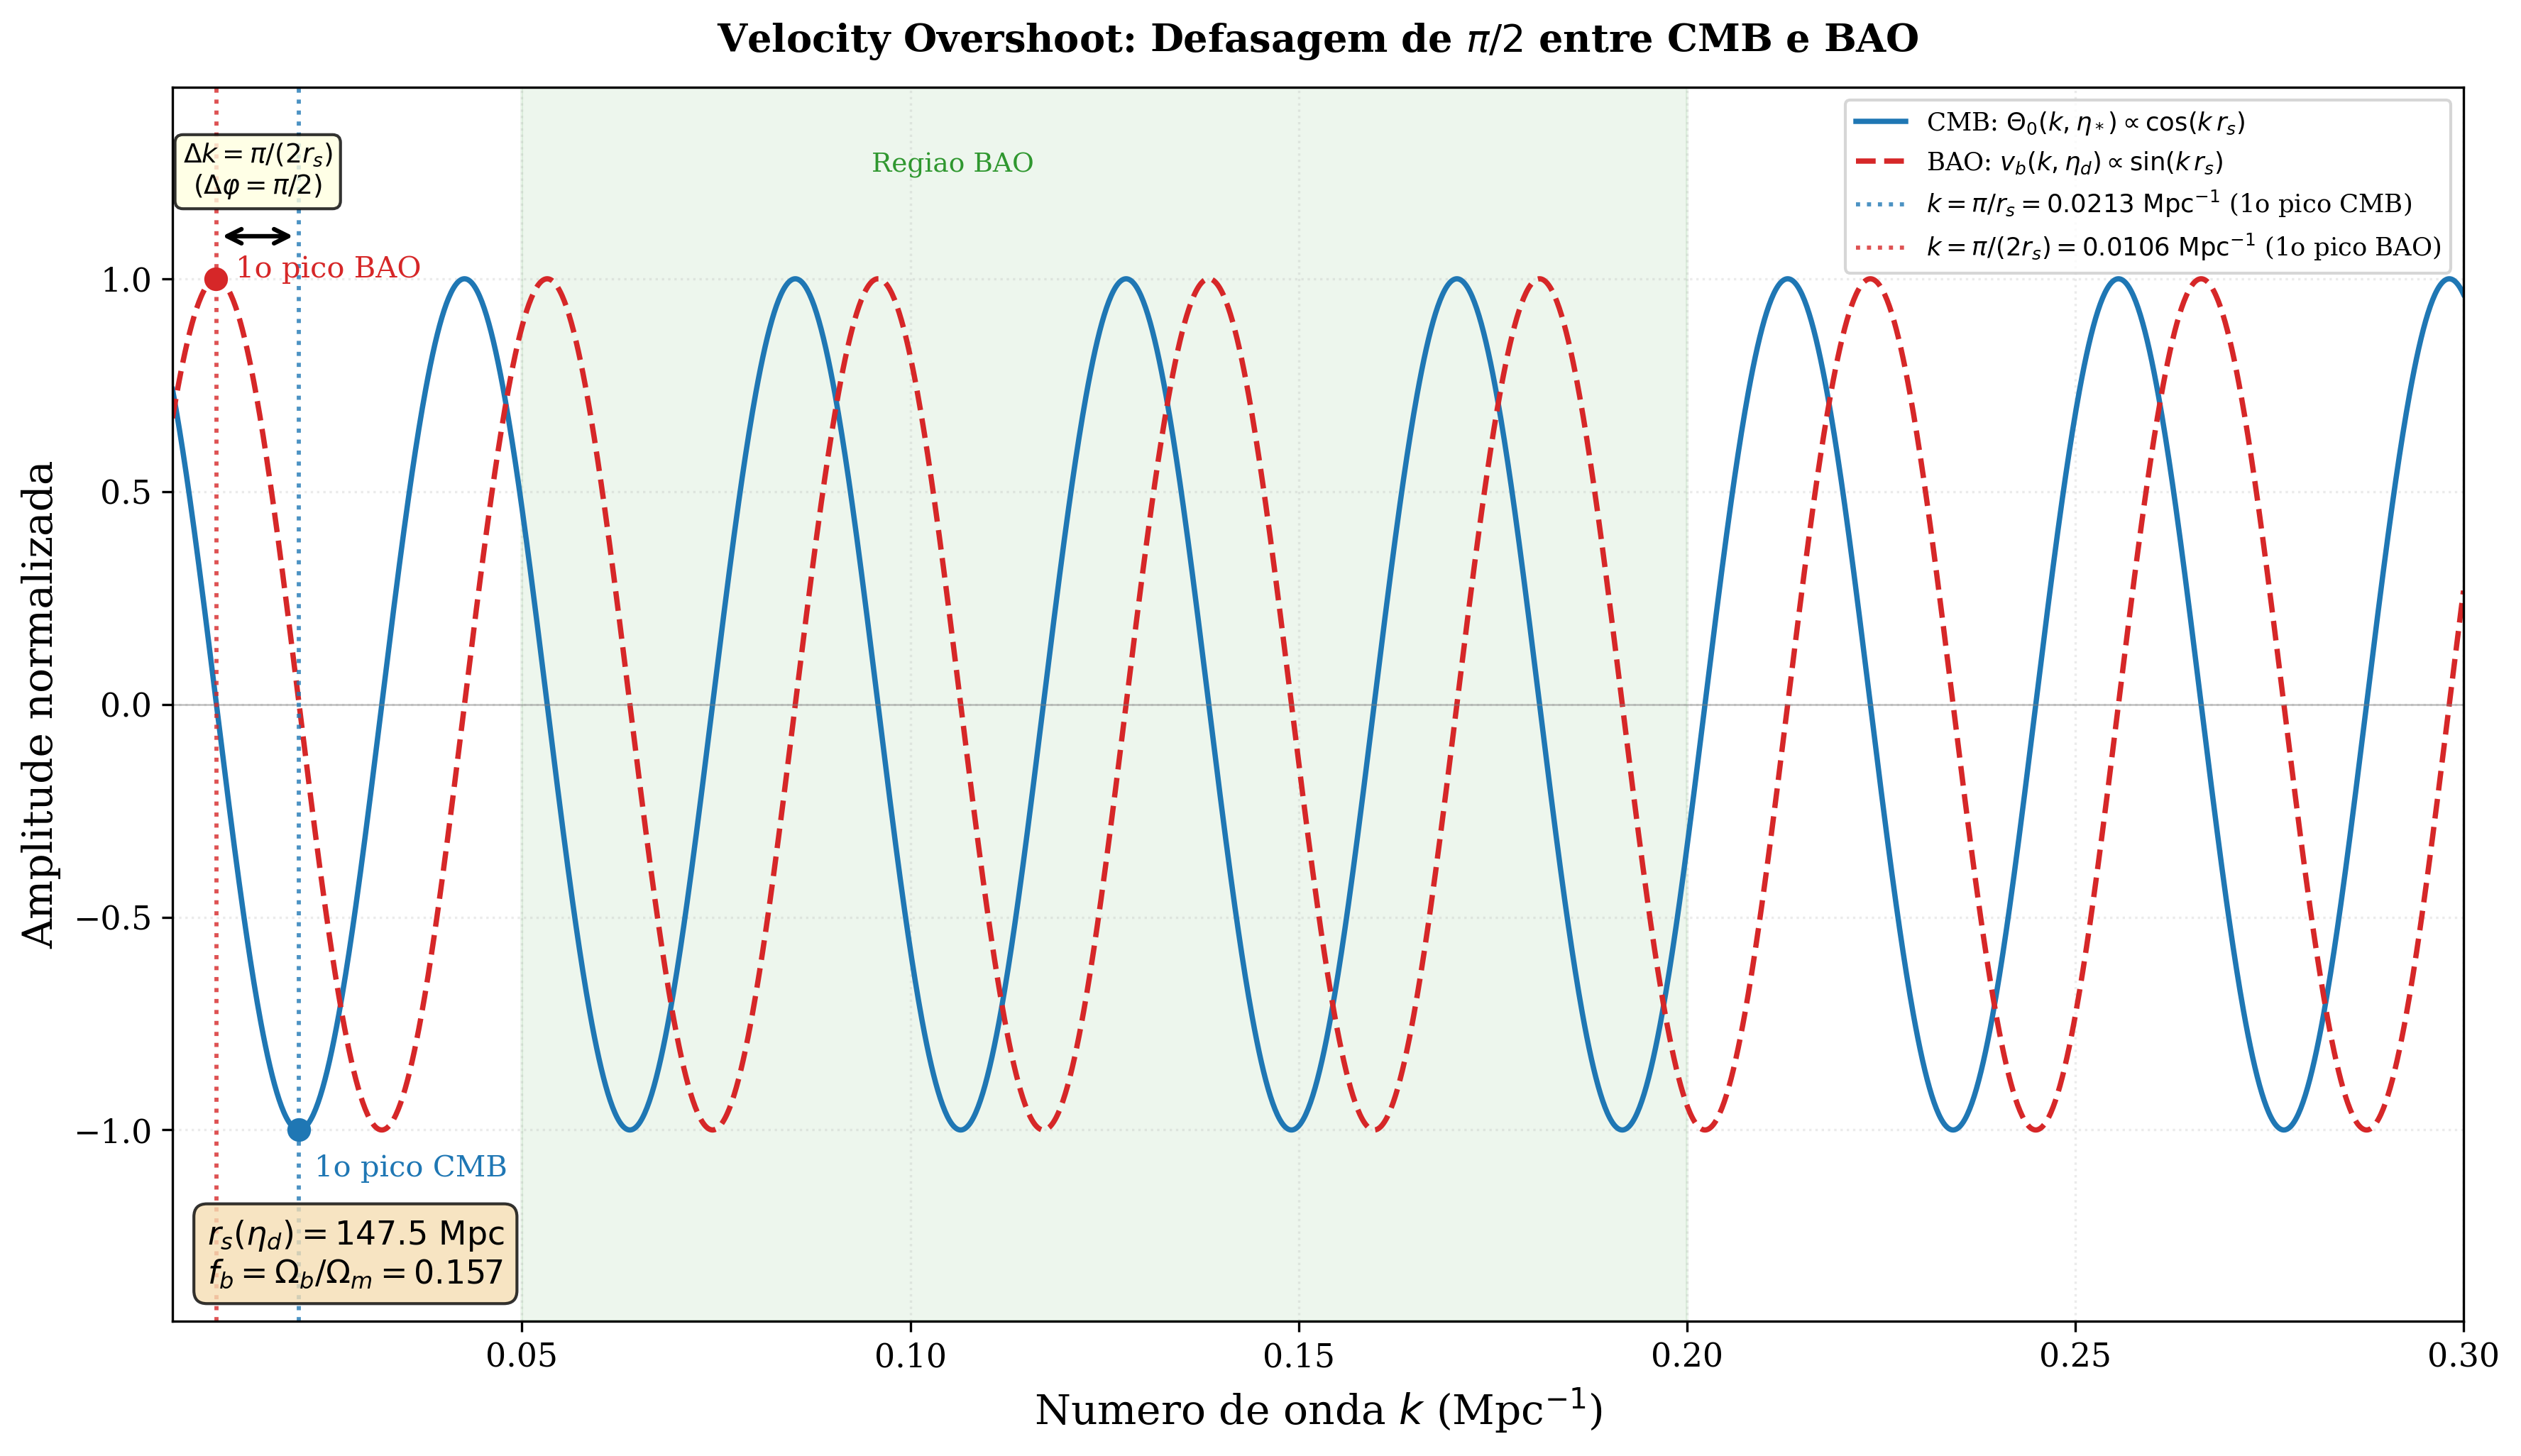


   k      k r_s/pi   cos(k r_s)   sin(k r_s) 
--------------------------------------------
 0.0106    0.500       0.0000       1.0000   
 0.0213    1.000      -1.0000       0.0000   
 0.0319    1.500      -0.0000      -1.0000   
 0.0426    2.000       1.0000      -0.0000   

Defasagem entre seno e cosseno: pi/2 = 1.5708 rad


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate


# =============================================================================
# CONFIGURACOES DE ESTILO
# =============================================================================

plt.style.use('default')

plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 13,
    'legend.fontsize': 10,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'lines.linewidth': 1.8,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'grid.linestyle': '--'
})


# =============================================================================
# PARAMETROS COSMOLOGICOS - Planck 2018
# =============================================================================

Omega_b_h2 = 0.0224
Omega_m = 0.315
h = 0.674

H0_si = h * 100 / 299792.458
Omega_r = 9.0e-5

Omega_b = Omega_b_h2 / h**2
f_b = Omega_b / Omega_m

z_star = 1090
z_d = 1060
z_max = 1e6


print(
    f"f_b = Omega_b / Omega_m = {f_b:.4f}"
)


# =============================================================================
# FUNCAO DE EXPANSAO E TEMPO CONFORME
# =============================================================================

def E(z):
    """
    Funcao adimensional associada a H(z).
    """

    return np.sqrt(
        Omega_m * (1 + z)**3
        + Omega_r * (1 + z)**4
        + (1 - Omega_m - Omega_r)
    )


def eta_c(z):
    """
    Calcula o tempo conforme correspondente ao redshift z.
    """

    integrand = lambda zp: 1 / (H0_si * E(zp))

    value, _ = integrate.quad(
        integrand,
        z,
        z_max,
        limit=500
    )

    return value


# =============================================================================
# GRADE DE REDSHIFT E TEMPO CONFORME
# =============================================================================

N = 5000

z_grid = np.logspace(
    0,
    np.log10(z_max),
    N
)[::-1]


eta_raw = np.array([
    eta_c(z)
    for z in z_grid
])


# Reordena a grade em ordem crescente de tempo conforme
order = np.argsort(eta_raw)

eta_s = eta_raw[order]
z_s = z_grid[order]


# Tempo conforme na recombinacao e no drag epoch
eta_star_val = eta_c(z_star)
eta_d_val = eta_c(z_d)


idx_d = np.argmin(
    np.abs(eta_s - eta_d_val)
)


print(
    f"eta_star = {eta_star_val:.2f} Mpc"
)

print(
    f"eta_d    = {eta_d_val:.2f} Mpc"
)


# =============================================================================
# HORIZONTE SONICO r_s(eta_d)
#
# A velocidade do som e calculada com R variavel.
# =============================================================================

def R_z(z):
    """
    Funcao R(z) para o fluido foton-barion.
    """

    a_d = 1 / (1 + z_d)

    return (
        0.6
        * (Omega_b_h2 / 0.02)
        * (a_d / 1e-3)
        * (1 + z_d) / (1 + z)
    )


R_g = R_z(z_s)


c_s_g = 1 / np.sqrt(
    3 * (1 + R_g)
)


# Horizonte sonico acumulado
r_s_g = integrate.cumulative_trapezoid(
    c_s_g,
    eta_s,
    initial=0
)


rs_d = r_s_g[idx_d]


print(
    f"r_s(eta_d) = {rs_d:.2f} Mpc"
    "  (integral com R(eta) variavel)"
)

erro_rs = abs(rs_d - 147.05) / 147.05 * 100

print(
    f"Planck 2018: r_s = 147.05 Mpc"
    f" -> erro = {erro_rs:.1f}%"
)


# =============================================================================
# SINAIS ACUSTICOS
#
# CMB:
#     Theta_0(k, eta_star) proporcional a cos(k r_s)
#
# BAO:
#     v_b(k, eta_d) proporcional a sin(k r_s)
#
# A defasagem entre seno e cosseno e pi/2.
# =============================================================================

k = np.linspace(
    0.005,
    0.30,
    2000
)


# Sinal associado ao monopolo de temperatura
cmb_signal = np.cos(
    k * rs_d
)


# Sinal associado a velocidade bariônica
bao_signal = np.sin(
    k * rs_d
)


# Verificacao da defasagem
phase_difference = np.pi / 2


print(
    f"\nDefasagem entre os sinais: "
    f"Delta_phi = pi/2 = {phase_difference:.4f} rad"
)


# =============================================================================
# GRAFICO PRINCIPAL
# =============================================================================

fig, ax = plt.subplots(
    figsize=(12, 7)
)


# Sinal CMB
ax.plot(
    k,
    cmb_signal,
    label=r'CMB: $\Theta_0(k,\eta_*) \propto \cos(k\,r_s)$',
    color='#1f77b4',
    linestyle='-',
    linewidth=1.8
)


# Sinal BAO
ax.plot(
    k,
    bao_signal,
    label=r'BAO: $v_b(k,\eta_d) \propto \sin(k\,r_s)$',
    color='#d62728',
    linestyle='--',
    linewidth=1.8
)


# Linha horizontal em zero
ax.axhline(
    0,
    color='gray',
    linewidth=0.6,
    alpha=0.5
)


# =============================================================================
# ESCALAS CARACTERISTICAS
# =============================================================================

k_cmb = np.pi / rs_d
k_bao = np.pi / (2 * rs_d)


# Primeiro pico CMB
ax.axvline(
    x=k_cmb,
    color='#1f77b4',
    linestyle=':',
    linewidth=1.4,
    alpha=0.8,
    label=(
        rf'$k = \pi/r_s = {k_cmb:.4f}\ '
        rf'\mathrm{{Mpc}}^{{-1}}$ (1o pico CMB)'
    )
)


# Primeiro pico BAO
ax.axvline(
    x=k_bao,
    color='#d62728',
    linestyle=':',
    linewidth=1.4,
    alpha=0.8,
    label=(
        rf'$k = \pi/(2r_s) = {k_bao:.4f}\ '
        rf'\mathrm{{Mpc}}^{{-1}}$ (1o pico BAO)'
    )
)


# =============================================================================
# REGIAO BAO OBSERVACIONAL
# =============================================================================

ax.axvspan(
    0.05,
    0.20,
    alpha=0.07,
    color='green'
)


ax.text(
    0.095,
    1.25,
    'Regiao BAO',
    fontsize=9,
    color='green',
    alpha=0.8
)


# =============================================================================
# EIXOS E FORMATACAO
# =============================================================================

ax.set_xlabel(
    r'Numero de onda $k$ (Mpc$^{-1}$)',
    fontsize=14
)

ax.set_ylabel(
    r'Amplitude normalizada',
    fontsize=14
)


ax.set_xlim(
    0.005,
    0.30
)

ax.set_ylim(
    -1.45,
    1.45
)


ax.tick_params(
    labelsize=11
)


ax.legend(
    loc='upper right',
    frameon=True,
    fontsize=8.5
)


ax.grid(
    True,
    alpha=0.25,
    linestyle=':'
)


ax.set_title(
    r'Velocity Overshoot: Defasagem de $\pi/2$ entre CMB e BAO',
    fontsize=13,
    fontweight='bold',
    pad=12
)


# =============================================================================
# MARCACAO DOS PRIMEIROS PICOS
# =============================================================================

idx_p1_cmb = np.argmin(
    np.abs(k - k_cmb)
)

idx_p1_bao = np.argmin(
    np.abs(k - k_bao)
)


# Primeiro pico CMB
ax.plot(
    k[idx_p1_cmb],
    cmb_signal[idx_p1_cmb],
    'o',
    color='#1f77b4',
    markersize=7,
    zorder=5
)


# Primeiro pico BAO
ax.plot(
    k[idx_p1_bao],
    bao_signal[idx_p1_bao],
    'o',
    color='#d62728',
    markersize=7,
    zorder=5
)


# Anotacao do primeiro pico CMB
ax.annotate(
    '1o pico CMB',
    xy=(
        k[idx_p1_cmb],
        cmb_signal[idx_p1_cmb]
    ),
    xytext=(
        k[idx_p1_cmb] + 0.002,
        cmb_signal[idx_p1_cmb] - 0.11
    ),
    fontsize=10,
    color='#1f77b4'
)


# Anotacao do primeiro pico BAO
ax.annotate(
    '1o pico BAO',
    xy=(
        k[idx_p1_bao],
        bao_signal[idx_p1_bao]
    ),
    xytext=(
        k[idx_p1_bao] + 0.0025,
        bao_signal[idx_p1_bao] + 0.0025
    ),
    fontsize=10,
    color='#d62728'
)


# =============================================================================
# MARCACAO DA DEFASAGEM
# =============================================================================

ax.annotate(
    '',
    xy=(k_cmb, 1.1),
    xytext=(k_bao, 1.1),
    arrowprops=dict(
        arrowstyle='<->',
        color='black',
        lw=1.5
    )
)


midpoint_k = (k_cmb + k_bao) / 2


ax.text(
    midpoint_k,
    1.2,
    r'$\Delta k = \pi/(2r_s)$'
    '\n'
    r'$(\Delta\varphi = \pi/2)$',
    ha='center',
    fontsize=9,
    bbox=dict(
        boxstyle='round',
        facecolor='lightyellow',
        alpha=0.8
    )
)


# =============================================================================
# INFORMACOES NO GRAFICO
# =============================================================================

ax.text(
    0.015,
    0.025,
    rf'$r_s(\eta_d) = {rs_d:.1f}\ \mathrm{{Mpc}}$' '\n'
    rf'$f_b = \Omega_b/\Omega_m = {f_b:.3f}$',
    transform=ax.transAxes,
    fontsize=11,
    bbox=dict(
        boxstyle='round',
        facecolor='wheat',
        alpha=0.8,
        pad=0.4
    ),
    verticalalignment='bottom'
)


# =============================================================================
# SALVAMENTO
# =============================================================================

plt.tight_layout()


plt.savefig(
    'grafico4_velocity_overshoot_bao.png',
    dpi=300,
    bbox_inches='tight'
)

plt.savefig(
    'grafico4_velocity_overshoot_bao.pdf',
    dpi=300,
    bbox_inches='tight'
)


print("\nGrafico 4 salvo com sucesso.")


plt.show()


# =============================================================================
# VERIFICACAO QUANTITATIVA
# =============================================================================

print(
    f"\n{'k':^8} "
    f"{'k r_s/pi':^10} "
    f"{'cos(k r_s)':^12} "
    f"{'sin(k r_s)':^12}"
)

print("-" * 44)


k_values = [
    np.pi / (2 * rs_d),
    np.pi / rs_d,
    3 * np.pi / (2 * rs_d),
    2 * np.pi / rs_d
]


for k_test in k_values:

    phase = k_test * rs_d

    print(
        f"{k_test:^8.4f} "
        f"{phase / np.pi:^10.3f} "
        f"{np.cos(phase):^12.4f} "
        f"{np.sin(phase):^12.4f}"
    )


print(
    f"\nDefasagem entre seno e cosseno: "
    f"pi/2 = {np.pi / 2:.4f} rad"
)
